<a href="https://colab.research.google.com/github/Aarjoo2603/projects/blob/main/Week2_Aarjoo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload(
)

Saving tesla_deliveries_dataset_2015_2025.csv to tesla_deliveries_dataset_2015_2025.csv


In [3]:
import pandas as pd

df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [4]:
print(df.columns)

Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')


In [5]:
df.shape

(2640, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [7]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [8]:
df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


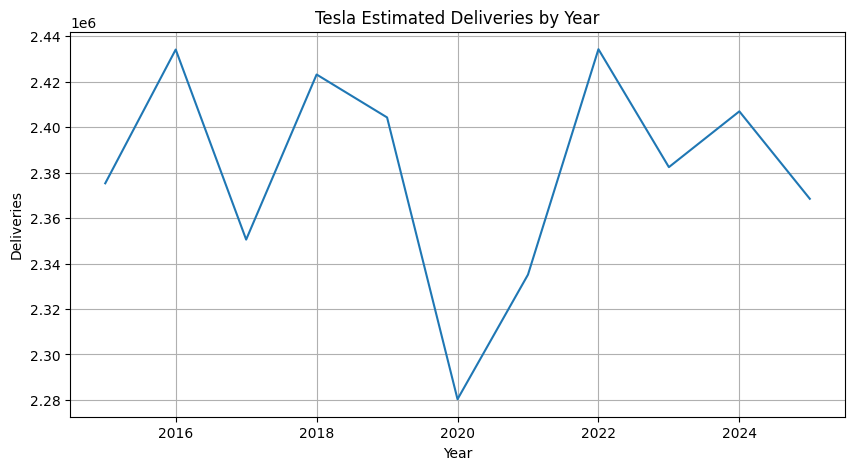

In [9]:
import matplotlib.pyplot as plt

yearly = df.groupby('Year')['Estimated_Deliveries'].sum()

plt.figure(figsize=(10,5))
plt.plot(yearly.index, yearly.values)
plt.title('Tesla Estimated Deliveries by Year')
plt.xlabel('Year')
plt.ylabel('Deliveries')
plt.grid(True)
plt.show()

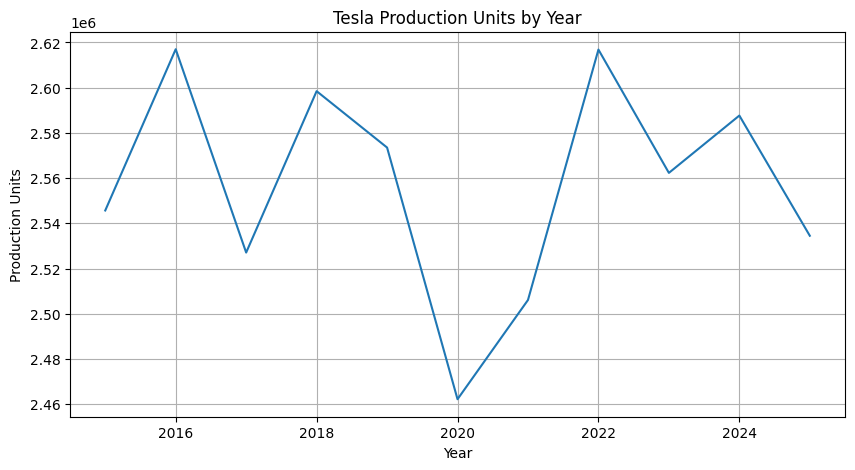

In [10]:
production = df.groupby('Year')['Production_Units'].sum()

plt.figure(figsize=(10,5))
plt.plot(production.index, production.values)
plt.title('Tesla Production Units by Year')
plt.xlabel('Year')
plt.ylabel('Production Units')
plt.grid(True)
plt.show()

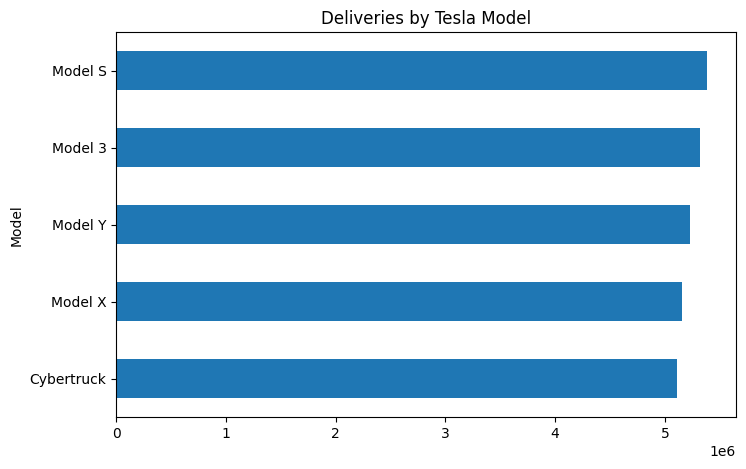

In [11]:
model_sales = df.groupby('Model')['Estimated_Deliveries'].sum()

plt.figure(figsize=(8,5))
model_sales.sort_values().plot(kind='barh')
plt.title('Deliveries by Tesla Model')
plt.show()

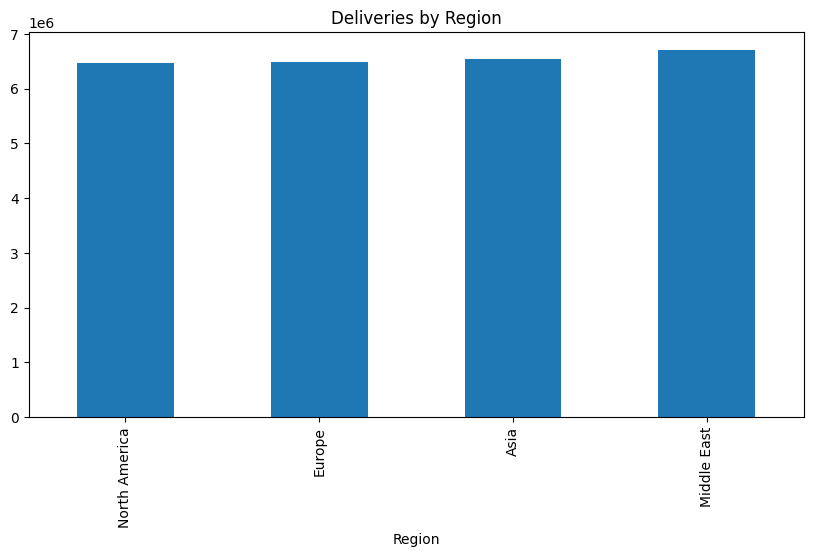

In [12]:
region_sales = df.groupby('Region')['Estimated_Deliveries'].sum()

plt.figure(figsize=(10,5))
region_sales.sort_values().plot(kind='bar')
plt.title('Deliveries by Region')
plt.show()

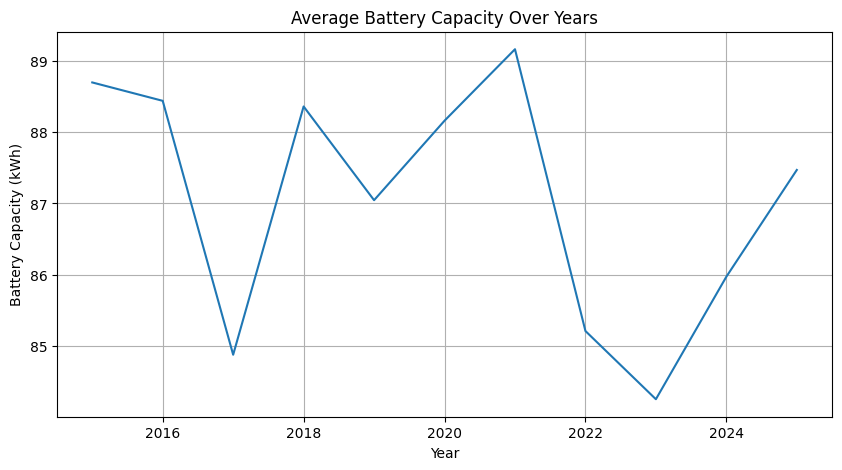

In [13]:
battery = df.groupby('Year')['Battery_Capacity_kWh'].mean()

plt.figure(figsize=(10,5))
plt.plot(battery.index, battery.values)
plt.title('Average Battery Capacity Over Years')
plt.xlabel('Year')
plt.ylabel('Battery Capacity (kWh)')
plt.grid(True)
plt.show()

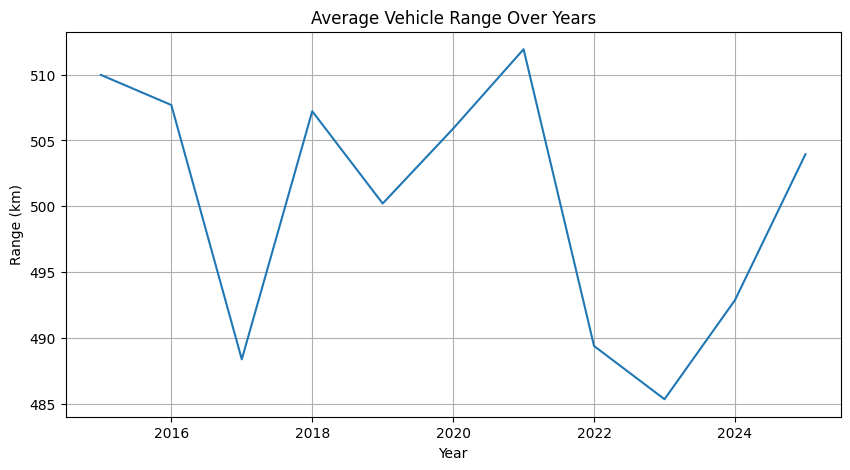

In [14]:
range_data = df.groupby('Year')['Range_km'].mean()

plt.figure(figsize=(10,5))
plt.plot(range_data.index, range_data.values)
plt.title('Average Vehicle Range Over Years')
plt.xlabel('Year')
plt.ylabel('Range (km)')
plt.grid(True)
plt.show()

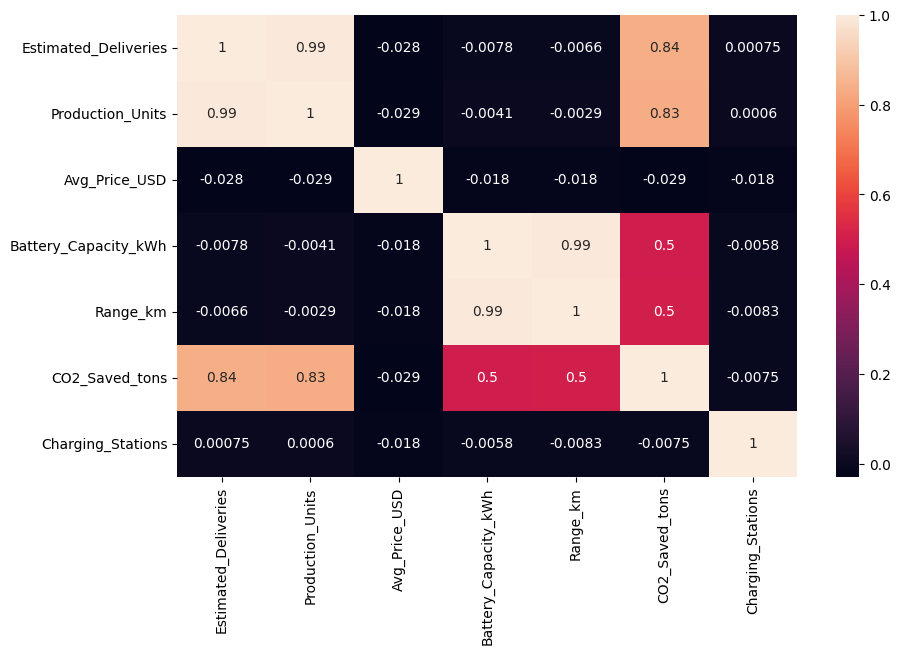

In [15]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(
    df[['Estimated_Deliveries',
        'Production_Units',
        'Avg_Price_USD',
        'Battery_Capacity_kWh',
        'Range_km',
        'CO2_Saved_tons',
        'Charging_Stations']].corr(),
    annot=True
)

plt.show()